In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import SelectFromModel
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Load train dataset

In [ ]:
train=pd.read_csv(r"2_Data_feature_Fragmentomic exploration_Training set.csv",sep=',')
train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Columns: 10793 entries, SampleID to NONBS_RATIO_ST_Y:9000001-10000000
dtypes: float64(10788), int64(1), object(4)
memory usage: 41.8+ MB


,SampleID,Class,Label,Stage,Run,NONBS_FLEN_50,NONBS_FLEN_51,NONBS_FLEN_52,NONBS_FLEN_53,NONBS_FLEN_54,...,NONBS_RATIO_ST_X:95000001-96000000,NONBS_RATIO_ST_X:96000001-97000000,NONBS_RATIO_ST_X:97000001-98000000,NONBS_RATIO_ST_X:98000001-99000000,NONBS_RATIO_ST_X:99000001-100000000,NONBS_RATIO_ST_Y:10000001-11000000,NONBS_RATIO_ST_Y:13000001-14000000,NONBS_RATIO_ST_Y:58000001-59000000,NONBS_RATIO_ST_Y:59000001-59373566,NONBS_RATIO_ST_Y:9000001-10000000
0,HNCRC05,CRC,1,Stage III,R7120,0.0,0.0,0.0,0.0,0.0,...,0.173973,0.179143,0.169063,0.179278,0.152975,0.199798,0.308913,0.287285,0.195266,0.182400
1,HNCRC20,CRC,1,Stage II,R7150,0.0,0.0,0.0,0.0,0.0,...,0.151879,0.154345,0.154746,0.156080,0.153875,0.186472,0.284327,0.259778,0.204545,0.161410
2,K0AAAE98,PreK,1,NaN,R6041,0.0,0.0,0.0,0.0,0.0,...,0.151463,0.159494,0.146286,0.147195,0.151057,0.156317,0.291745,0.218136,0.182077,0.139210
3,K0AAAH79R1,PreK,1,NaN,R7933,0.0,0.0,0.0,0.0,0.0,...,0.167860,0.170385,0.168850,0.181004,0.171216,0.213813,0.284714,0.217645,0.190896,0.158455
4,K0AAAW11,PreK,1,NaN,R5891i2,0.0,0.0,0.0,0.0,0.0,...,0.189740,0.203111,0.183852,0.188360,0.175759,0.231016,0.320418,0.266263,0.187500,0.181034


In [3]:
train['Class'].value_counts()

Class
Healthy    250
CRC        189
PreK        69
Name: count, dtype: int64

In [ ]:
y_train = train['Label']
X_train = train.drop(["SampleID","Class","Label","Stage","Run"],axis=1)
X_train


,NONBS_FLEN_50,NONBS_FLEN_51,NONBS_FLEN_52,NONBS_FLEN_53,NONBS_FLEN_54,NONBS_FLEN_55,NONBS_FLEN_56,NONBS_FLEN_57,NONBS_FLEN_58,NONBS_FLEN_59,...,NONBS_RATIO_ST_X:95000001-96000000,NONBS_RATIO_ST_X:96000001-97000000,NONBS_RATIO_ST_X:97000001-98000000,NONBS_RATIO_ST_X:98000001-99000000,NONBS_RATIO_ST_X:99000001-100000000,NONBS_RATIO_ST_Y:10000001-11000000,NONBS_RATIO_ST_Y:13000001-14000000,NONBS_RATIO_ST_Y:58000001-59000000,NONBS_RATIO_ST_Y:59000001-59373566,NONBS_RATIO_ST_Y:9000001-10000000
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.173973,0.179143,0.169063,0.179278,0.152975,0.199798,0.308913,0.287285,0.195266,0.182400
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.151879,0.154345,0.154746,0.156080,0.153875,0.186472,0.284327,0.259778,0.204545,0.161410
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.151463,0.159494,0.146286,0.147195,0.151057,0.156317,0.291745,0.218136,0.182077,0.139210
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.167860,0.170385,0.168850,0.181004,0.171216,0.213813,0.284714,0.217645,0.190896,0.158455
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.189740,0.203111,0.183852,0.188360,0.175759,0.231016,0.320418,0.266263,0.187500,0.181034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.142178,0.157177,0.147775,0.149440,0.147903,0.223647,0.384865,0.273151,0.195980,0.169323
504,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.163915,0.168559,0.166618,0.161540,0.151674,0.240822,0.431620,0.273273,0.169014,0.186589
505,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.136766,0.138062,0.150533,0.140614,0.143365,0.199796,0.388355,0.250386,0.163158,0.165835
506,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.130633,0.140009,0.125216,0.132923,0.136258,0.156182,0.288827,0.202471,0.150424,0.159884


Load Validation dataset

In [ ]:
test=pd.read_csv(r"3_Data_feature_Fragmentomic exxploration_Test set.csv",sep=',')
test.info()
test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Columns: 10793 entries, SampleID to NONBS_RATIO_ST_Y:9000001-10000000
dtypes: float64(10786), int64(3), object(4)
memory usage: 39.2+ MB


,SampleID,Class,Label,Stage,Run,NONBS_FLEN_50,NONBS_FLEN_51,NONBS_FLEN_52,NONBS_FLEN_53,NONBS_FLEN_54,...,NONBS_RATIO_ST_X:95000001-96000000,NONBS_RATIO_ST_X:96000001-97000000,NONBS_RATIO_ST_X:97000001-98000000,NONBS_RATIO_ST_X:98000001-99000000,NONBS_RATIO_ST_X:99000001-100000000,NONBS_RATIO_ST_Y:10000001-11000000,NONBS_RATIO_ST_Y:13000001-14000000,NONBS_RATIO_ST_Y:58000001-59000000,NONBS_RATIO_ST_Y:59000001-59373566,NONBS_RATIO_ST_Y:9000001-10000000
0,MEAAAA64,CRC,1,Stage NA,R8412,0.0,0.0,0.0,0.0,0.0,...,0.152944,0.166731,0.153032,0.159172,0.144800,0.179941,0.291906,0.270680,0.120690,0.144310
1,MEAAAA71,CRC,1,Stage NA,R8412,0.0,0.0,0.0,0.0,0.0,...,0.128156,0.135729,0.130400,0.121682,0.123427,0.155136,0.345606,0.242405,0.146341,0.153285
2,MEAAAB09,CRC,1,Stage NA,R8412,0.0,0.0,0.0,0.0,0.0,...,0.145521,0.153965,0.155895,0.141019,0.155028,0.172230,0.280825,0.228922,0.151724,0.131133
3,MEAAAB11,CRC,1,Stage NA,R8412,0.0,0.0,0.0,0.0,0.0,...,0.162645,0.170724,0.153428,0.164547,0.149056,0.176252,0.357018,0.276146,0.218935,0.221805
4,MECAAC18,CRC,1,Stage NA,R8412,0.0,0.0,0.0,0.0,0.0,...,0.211965,0.219650,0.200150,0.218422,0.216532,0.242004,0.344303,0.284349,0.202808,0.196217


In [ ]:
y_test = test['Label']
X_test = test.drop(["SampleID","Class","Label","Stage","Run"],axis=1)
X_test


,NONBS_FLEN_50,NONBS_FLEN_51,NONBS_FLEN_52,NONBS_FLEN_53,NONBS_FLEN_54,NONBS_FLEN_55,NONBS_FLEN_56,NONBS_FLEN_57,NONBS_FLEN_58,NONBS_FLEN_59,...,NONBS_RATIO_ST_X:95000001-96000000,NONBS_RATIO_ST_X:96000001-97000000,NONBS_RATIO_ST_X:97000001-98000000,NONBS_RATIO_ST_X:98000001-99000000,NONBS_RATIO_ST_X:99000001-100000000,NONBS_RATIO_ST_Y:10000001-11000000,NONBS_RATIO_ST_Y:13000001-14000000,NONBS_RATIO_ST_Y:58000001-59000000,NONBS_RATIO_ST_Y:59000001-59373566,NONBS_RATIO_ST_Y:9000001-10000000
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.152944,0.166731,0.153032,0.159172,0.144800,0.179941,0.291906,0.270680,0.120690,0.144310
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.128156,0.135729,0.130400,0.121682,0.123427,0.155136,0.345606,0.242405,0.146341,0.153285
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.145521,0.153965,0.155895,0.141019,0.155028,0.172230,0.280825,0.228922,0.151724,0.131133
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.162645,0.170724,0.153428,0.164547,0.149056,0.176252,0.357018,0.276146,0.218935,0.221805
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.211965,0.219650,0.200150,0.218422,0.216532,0.242004,0.344303,0.284349,0.202808,0.196217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.153433,0.171093,0.154779,0.171075,0.159762,0.167523,0.321702,0.243603,0.185824,0.158458
472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.169099,0.178910,0.160745,0.164823,0.169867,0.189342,0.300817,0.234503,0.165152,0.164057
473,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.152069,0.163825,0.156593,0.157420,0.153958,0.214162,0.391901,0.310659,0.187617,0.205882
474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.119285,0.120553,0.128343,0.121227,0.121429,0.159624,0.330172,0.245570,0.151111,0.139130


In [9]:
test['Class'].value_counts()

Class
Healthy    236
CRC        190
PreK        50
Name: count, dtype: int64

In [10]:
X_train=X_train.values
X_train

array([[0.        , 0.        , 0.        , ..., 0.28728489, 0.19526627,
        0.1824    ],
       [0.        , 0.        , 0.        , ..., 0.25977769, 0.20454545,
        0.16141002],
       [0.        , 0.        , 0.        , ..., 0.218136  , 0.182077  ,
        0.13921   ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.2503864 , 0.16315789,
        0.16583541],
       [0.        , 0.        , 0.        , ..., 0.20247148, 0.15042373,
        0.15988372],
       [0.        , 0.        , 0.        , ..., 0.29071395, 0.20984081,
        0.18117977]])

Search best thuật toán

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
models = {
    'LR': LogisticRegression(max_iter=200),
    'SVM': SVC(max_iter=-1),
    'XGB':XGBClassifier()
}
params = { 
    'LR': { 'C': [1.0], 'class_weight':[None] },
    'SVM' : {'kernel':['rbf']},
    'XGB': {'n_estimators':[100],'max_depth':[3],'learning_rate':[0.01]}
}

In [12]:
from HyperclassifierSearch import HyperclassifierSearch
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
search = HyperclassifierSearch(models,params)
best_model = search.train_model(X_train, y_train, cv=cv)

Search for LR ...
Search for SVM ...
Search for XGB ...
Search is done.


In [13]:
result = search.evaluate_model()
result

results round for: LR
results round for: SVM
results round for: XGB


,Estimator,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score
0,XGB,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.607843,0.764706,0.764706,0.725490,0.666667,0.627451,0.627451,0.647059,0.72,0.60,0.675137,0.060146
1,LR,"{'C': 1.0, 'class_weight': None}",0.627451,0.627451,0.705882,0.666667,0.568627,0.549020,0.568627,0.607843,0.60,0.68,0.620157,0.049121
2,SVM,{'kernel': 'rbf'},0.490196,0.549020,0.588235,0.568627,0.509804,0.588235,0.568627,0.529412,0.54,0.50,0.543216,0.033726


In [ ]:
result.to_csv(r"Compare_accuracy_1D model.csv", index=False)

results round for: LR
results round for: SVM
results round for: XGB


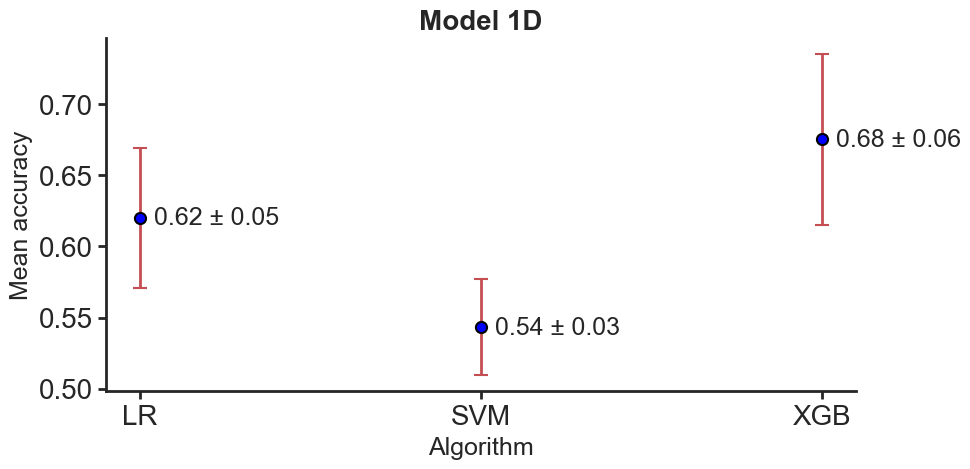

In [44]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'

# Assuming result is a DataFrame from search.evaluate_model()
result = search.evaluate_model()
order = ["LR", "SVM", "XGB"]

result["label"] = result["Estimator"].astype(str)
result["label"] = pd.Categorical(
    result["label"],
    categories=order,
    ordered=True
)

result = result.sort_values("label")

# Extract algorithm names for labels
result['label'] = result['Estimator'].astype(str)

std = result['std_test_score'].to_list()
mean_ = result['mean_test_score'].to_list()
x = result['label'].to_list()

# Set up the matplotlib figure
plt.figure(figsize=(10,5))

# Create error bar plot
plt.errorbar(x, mean_, yerr=std, fmt='o', ecolor='r', elinewidth=2, capsize=5, capthick=2, markersize=8, markerfacecolor='blue', markeredgewidth=1.5, markeredgecolor='black')

# Annotate each point with its accuracy and standard deviation, positioned slightly above the error bar
for i in range(len(x)):
    plt.annotate(f'{mean_[i]:.2f} ± {std[i]:.2f}',(x[i], mean_[i]), textcoords="offset points", xytext=(10,-5), ha='left', fontsize=18)

# Add title and labels
# plt.ylim(0.6,0.95)
plt.title('Model 1D', fontsize=20,fontweight='bold')
plt.xlabel('Algorithm', fontsize=18)
plt.ylabel('Mean accuracy', fontsize=18)

plt.tick_params(axis='both', labelsize=20, width=2,length=6)

for spine in ['left', 'bottom']:
        plt.gca().spines[spine].set_linewidth(2)  # hoặc 2.5, 3

        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)


# Tight layout for better spacing
plt.tight_layout()

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Show plot
plt.show()

Gridsearch parameter

In [17]:
def compute_specificity(y_true, y_pred):
    true_negatives = sum((y_true == 0) & (y_pred == 0))
    actual_negatives = sum(y_true == 0)
    specificity = true_negatives / actual_negatives if actual_negatives != 0 else 0
    return specificity

In [18]:
def compute_sensitivity(y_true, y_pred):
    true_positives = sum((y_true == 1) & (y_pred == 1))
    actual_positives = sum(y_true == 1)
    sensitivity = true_positives / actual_positives if actual_positives != 0 else 0
    return sensitivity

In [19]:
# Define a custom scoring function
def custom_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)
    score = round(((specificity + sensitivity)/2 +specificity)/2, 2)
    return score

# Make the custom scoring function
from sklearn.metrics import make_scorer
custom_scorer = make_scorer(custom_score, greater_is_better=True)

In [20]:
from sklearn.utils import resample
from scipy.stats import norm
def compute_metrics_with_ci(y_true, y_pred, num_bootstraps=1000, confidence_level=0.95):
    specificity_scores = []
    sensitivity_scores = []

    # Bootstrap resampling
    for _ in range(num_bootstraps):
        boot_true, boot_pred = resample(y_true, y_pred)
        specificity = compute_specificity(boot_true, boot_pred)
        sensitivity = compute_sensitivity(boot_true, boot_pred)
        specificity_scores.append(specificity)
        sensitivity_scores.append(sensitivity)

    # Compute mean and confidence interval
    specificity_mean = np.mean(specificity_scores)
    sensitivity_mean = np.mean(sensitivity_scores)
    specificity_ci = norm.interval(confidence_level, loc=specificity_mean, scale=np.std(specificity_scores))
    sensitivity_ci = norm.interval(confidence_level, loc=sensitivity_mean, scale=np.std(sensitivity_scores))

    return {
        'specificity_mean': specificity_mean,
        'specificity_ci': specificity_ci,
        'sensitivity_mean': sensitivity_mean,
        'sensitivity_ci': sensitivity_ci
    }


In [21]:
def create_ml_model(model_type, **kwargs):
    '''
    Create Machine Learning model
    '''
    models = {
        'svm': SVC,
        'random_forest': RandomForestClassifier,
        'logistic_regression': LogisticRegression,
        'xgb': XGBClassifier,
        'lightgbm':lgb,
        'lda': LinearDiscriminantAnalysis
    }
    
    # Retrieve the model class based on the model_type argument
    model = models.get(model_type.lower())
    
    # Check if the model type exists
    if model:
        return model(**kwargs)
    else:
        supported_models = ", ".join(models.keys())
        print(f"Error: Model type '{model_type}' is not supported.\n"
              f"Supported models are: {supported_models}.\n"
              f"Please add your perferred model to create_model function.")
        return None

In [22]:
def kfold_evaluation(model, X, y, kfold):
    '''
    1. Train ML model on KFold
    
    2. Return metrics for each KFold and all KFolds
    '''
    fold_results = [] # average validation data results on all Kfolds
    fold_result_each_kfold = [] # training and validation results on each Kfold

    for train_index, val_index in skf.split(X, y):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict on both sets
        train_predictions = model.predict(X_train)
        val_predictions = model.predict(X_val)
        
        # Calculate metrics for both sets
        train_metrics = calculate_results(y_train, train_predictions)
        val_metrics = calculate_results(y_val, val_predictions)

        fold_result = {
            'fold': len(fold_results) + 1,
            'train_metrics': train_metrics,
            'validation_metrics': val_metrics
        }

        fold_results.append(val_metrics)
        fold_result_each_kfold.append(fold_result)

    # Compute the average metrics over all folds
    model_results = {
        "accuracy": np.mean([result["accuracy"] for result in fold_results]),
        "precision": np.mean([result["precision"] for result in fold_results]),
        "recall": np.mean([result["recall"] for result in fold_results]),
        "f1": np.mean([result["f1"] for result in fold_results])
    }

    # Retrain the model on the entire dataset
    model.fit(X, y)

    return model, fold_result_each_kfold, model_results

In [ ]:
# def kfold_evaluation(model, X, y, kfold, groups):
#     '''
#     1. Train ML model using k-fold cross-validation with robust normalization 
#        based only on healthy samples in the training fold.
    
#     2. Return model trained on full data, metrics per fold, and averaged metrics.
#     '''
#     from sklearn.preprocessing import RobustScaler
#     import numpy as np

#     fold_results = []  # validation metrics for averaging
#     fold_result_each_kfold = []  # detailed train/val metrics per fold
#     for fold, (train_index, val_index) in enumerate(kfold.split(X, y)):
#         # Split data
#         X_train, X_val = X[train_index], X[val_index]
#         y_train, y_val = y[train_index], y[val_index]
#         groups_train = groups.iloc[train_index]

#         # Normalize using only healthy samples in training fold
#         healthy_mask = groups_train == 'Healthy'
#         X_train_healthy = X_train[healthy_mask]

#         scaler = RobustScaler()
#         scaler.fit(X_train_healthy)

#         X_train_scaled = scaler.transform(X_train)
#         X_val_scaled = scaler.transform(X_val)

#         # Train model on scaled data
#         model.fit(X_train_scaled, y_train)

#         # Predict
#         train_predictions = model.predict(X_train_scaled)
#         val_predictions = model.predict(X_val_scaled)

#         # Calculate metrics (define calculate_results beforehand)
#         train_metrics = calculate_results(y_train, train_predictions)
#         val_metrics = calculate_results(y_val, val_predictions)

#         fold_result = {
#             'fold': fold + 1,
#             'train_metrics': train_metrics,
#             'validation_metrics': val_metrics
#         }

#         fold_results.append(val_metrics)
#         fold_result_each_kfold.append(fold_result)

#     # Compute mean metrics over all folds
#     model_results = {
#         "accuracy": np.mean([res["accuracy"] for res in fold_results]),
#         "precision": np.mean([res["precision"] for res in fold_results]),
#         "recall": np.mean([res["recall"] for res in fold_results]),
#         "f1": np.mean([res["f1"] for res in fold_results])
#     }

#     # Retrain model on full dataset
#     model.fit(X, y)

#     return model, fold_result_each_kfold, model_results


In [23]:
from sklearn.metrics import precision_recall_fscore_support
def calculate_results(y_true, y_pred):
    '''
    Calculate accuracy, precision, recall, f1 score for a model
    '''
    model_accuracy = accuracy_score(y_true, y_pred) * 100  # Scale to 1-100
    model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    
    model_results = {
        "accuracy": model_accuracy,
        "precision": model_precision,
        "recall": model_recall,
        "f1": model_f1
    }
    
    return model_results

In [24]:
def compare_baseline_to_new_results(baseline_results, new_model_results, baseline_name='Baseline', new_model_name='New Model'):
    '''
    Compare baseline and new model results on metrics and plot the results using a line graph.
    '''
    metrics = list(baseline_results.keys())
    baseline_scores = [baseline_results[metric] * 100 if metric != 'accuracy' else baseline_results[metric] for metric in metrics]
    new_model_scores = [new_model_results[metric] * 100 if metric != 'accuracy' else new_model_results[metric] for metric in metrics]

    # Textual comparison
    # for key, value in baseline_results.items():
        # print(f"{baseline_name} {key}: {value:.2f}, {new_model_name} {key}: {new_model_results[key]:.2f}, Difference: {new_model_results[key]-value:.2f}")

    # Set up the seaborn style and palette
    sns.set(style="whitegrid", palette="muted")
    colors = ["#3498db", "#e74c3c"]  # Blue for baseline, Red for new model

    # Plotting
    x = np.arange(len(metrics))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, baseline_scores, label=baseline_name, marker='o', markersize=6, linewidth=2, color=colors[0])
    ax.plot(x, new_model_scores, label=new_model_name, marker='s', markersize=6, linewidth=2, color=colors[1])
    
    # Adjust y-axis range
    max_score = max(max(baseline_scores), max(new_model_scores))
    min_score = min(min(baseline_scores), min(new_model_scores))
    ax.set_ylim([min_score - 1, max_score + 1])  # Add padding to the top and bottom
    ax.set_facecolor('#f8f9fa')  # Light gray background

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Scores (%)')
    ax.set_title(f'Performance Comparison: {baseline_name} vs {new_model_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()

    # Attach a text label at each marker, displaying its height with increased vertical offset
    label_offset = 0.25  # Increased vertical offset for the labels
    for i in range(len(metrics)):
        ax.text(x[i], baseline_scores[i] + label_offset, f'{baseline_scores[i]:.2f}%', ha='center', va='bottom')
        ax.text(x[i], new_model_scores[i] + label_offset, f'{new_model_scores[i]:.2f}%', ha='center', va='bottom')

    fig.tight_layout()
    plt.show()

In [25]:
def format_metrics_compact(metrics):
    '''
    Helper function to format metrics compactly
    '''
    return ", ".join([f"{key.capitalize()}: {value:.2f}" for key, value in metrics.items()])

def display_all_folds_results(model_name, model_results):
    '''
    Print average metrics of validation data on all KFolds
    '''
    print(f"Average {model_name} Performance Metrics Across All Folds (on validation data):")
    print(f"- Accuracy: {model_results['accuracy']:.2f}%")
    print(f"- Precision: {model_results['precision']:.4f}")
    print(f"- Recall: {model_results['recall']:.4f}")
    print(f"- F1 Score: {model_results['f1']:.4f}")

In [26]:
def display_each_fold_result(model_name, fold_results):
    '''
    Print metrics of training and validation data on each KFold and plot the accuracy graph using Seaborn.
    '''
    # Set up the seaborn style and palette
    sns.set(style="whitegrid", palette="muted")
    # colors = ["#3498db", "#e74c3c"]  
    colors = ["r", "b"]

    # Header
    print(f"{model_name} Performance Metrics Across Each Fold (on training and validation data):")
    print()
    print(f"{'Fold':<5} | {'Training Metrics':<70} | {'Validation Metrics':<70}")
    print("-" * 150)

    # Prepare data for plotting
    train_accuracies = []
    val_accuracies = []
    folds = []

    # Display results for each fold and collect data for graph
    for result in fold_results:
        train_metrics_formatted = format_metrics_compact(result['train_metrics'])
        val_metrics_formatted = format_metrics_compact(result['validation_metrics'])
        print(f"{result['fold']:<5} | {train_metrics_formatted:<70} | {val_metrics_formatted:<70}")

        # Append data for graph
        folds.append(result['fold'])
        train_accuracies.append(result['train_metrics']['accuracy'])
        val_accuracies.append(result['validation_metrics']['accuracy'])

    # Plotting the accuracies using Seaborn
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(x=folds, y=train_accuracies, label='Training Accuracy', marker='o', color=colors[0])
    sns.lineplot(x=folds, y=val_accuracies, label='Validation Accuracy', marker='o', color=colors[1])
    ax.set_facecolor('#f8f9fa')  # Light gray background

    # Adding percentages on markers
    label_offset = 0.25  # Increased vertical offset for the labels
    for i, (tr_acc, val_acc) in enumerate(zip(train_accuracies, val_accuracies)):
        ax.text(folds[i], tr_acc + label_offset, f"{tr_acc:.2f}%", ha='center', va='bottom')
        ax.text(folds[i], val_acc + label_offset, f"{val_acc:.2f}%", ha='center', va='bottom')

    plt.title(f"{model_name} model: Training vs Validation Accuracy per Fold")
    plt.xlabel('Fold')
    plt.ylabel('Accuracy (%)')
    plt.xticks(folds)
    plt.legend()
    ax.margins(y=1)  # Add 10% padding to the top and bottom
    fig.tight_layout()
    plt.show()

Tunning hyperparemeter

Model 1: Logistic regression

In [390]:
# Grid searching key hyperparametres for ridge classifier
from sklearn.datasets import make_blobs
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import RidgeClassifier
# define models and parameters
model = LogisticRegression(class_weight ='balanced',random_state=1)
solvers = ['newton-cg', 'lbfgs', 'liblinear']
penalty = ['l2','l1','none']
c_values = np.power(10., np.arange(-4, 4))
# #define scoring
# y_predictions = model.predict(X_train)
# ranking_metric=ranking_metric(y_train, y_predictions)
# from sklearn.metrics import make_scorer
# scoring= make_scorer(ranking_metric, greater_is_better = True)
# define grid search
grid = dict(solver=solvers,penalty=penalty,C=c_values)
cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='roc_auc' ,error_score=0)
grid_result = grid_search.fit(X_train, y_train)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.761805 using {'C': np.float64(0.1), 'penalty': 'l2', 'solver': 'newton-cg'}
0.603769 (0.063496) with: {'C': np.float64(0.0001), 'penalty': 'l2', 'solver': 'newton-cg'}
0.603621 (0.063588) with: {'C': np.float64(0.0001), 'penalty': 'l2', 'solver': 'lbfgs'}
0.604083 (0.063271) with: {'C': np.float64(0.0001), 'penalty': 'l2', 'solver': 'liblinear'}
0.000000 (0.000000) with: {'C': np.float64(0.0001), 'penalty': 'l1', 'solver': 'newton-cg'}
0.000000 (0.000000) with: {'C': np.float64(0.0001), 'penalty': 'l1', 'solver': 'lbfgs'}
0.500000 (0.000000) with: {'C': np.float64(0.0001), 'penalty': 'l1', 'solver': 'liblinear'}
0.000000 (0.000000) with: {'C': np.float64(0.0001), 'penalty': 'none', 'solver': 'newton-cg'}
0.000000 (0.000000) with: {'C': np.float64(0.0001), 'penalty': 'none', 'solver': 'lbfgs'}
0.000000 (0.000000) with: {'C': np.float64(0.0001), 'penalty': 'none', 'solver': 'liblinear'}
0.634178 (0.066721) with: {'C': np.float64(0.001), 'penalty': 'l2', 'solver': 'newton-cg'}
0.6

c:\Users\VANTHITUONGVI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
400 fits failed out of a total of 720.
The score on these train-test partitions for these parameters will be set to 0.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\VANTHITUONGVI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\VANTHITUONGVI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  Fil

Model 2: SVM

In [103]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import RidgeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Define models and parameters
model = SVC(random_state=1, probability=True)
kernel = ['linear', 'poly', 'rbf', 'sigmoid']
c_values = [100, 10, 1.0, 0.1, 0.01]
class_weight = ['balanced', None]
gamma = ['scale', 'auto']
tol = [0.00001, 0.0001, 0.001, 0.01, 0.1]

# Define grid search
grid = dict(kernel=kernel, class_weight=class_weight, C=c_values, gamma=gamma, tol=tol)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='roc_auc', error_score=0, refit=True, verbose=3)
grid_result = grid_search.fit(X_train, y_train)

# Summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Fitting 10 folds for each of 400 candidates, totalling 4000 fits
Best: 0.904627 using {'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf', 'tol': 1e-05}
0.893041 (0.029826) with: {'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear', 'tol': 1e-05}
0.893041 (0.029826) with: {'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear', 'tol': 0.0001}
0.893041 (0.029826) with: {'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear', 'tol': 0.001}
0.892888 (0.029650) with: {'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear', 'tol': 0.01}
0.893491 (0.031154) with: {'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear', 'tol': 0.1}
0.886911 (0.027719) with: {'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'poly', 'tol': 1e-05}
0.886911 (0.027719) with: {'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'poly', 'tol': 0.0001}
0.886911 (0.

Model 4: XGB

In [ ]:
# example of grid searching key hyperparameters for RandomForestClassifier
from sklearn.datasets import make_blobs
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

model = XGBClassifier(objective='binary:logistic',random_state=1) 
n_estimators = [100, 1000]
max_depth = [3, 4, 5]
learning_rate=[0.1, 0.01]
# #define scoring
# y_predictions = model.predict(X_train)
# ranking_metric=ranking_metric(y_train, y_predictions)
# from sklearn.metrics import make_scorer
# scoring= make_scorer(ranking_metric, greater_is_better = True)
# define grid search
grid = dict(n_estimators=n_estimators,max_depth=max_depth,learning_rate=learning_rate)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=1, cv=cv, scoring='roc_auc',error_score=0)
grid_result = grid_search.fit(X_train, y_train)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Results of model

Model 1: Logistic regresstion

In [29]:
from sklearn.model_selection import StratifiedKFold

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [391]:
lr_model = create_ml_model('logistic_regression',C=0.1, penalty='l2',solver='newton-cg',class_weight ='balanced',random_state=1)

In [392]:
groups = train['Class']

In [393]:
lr_model, lr_each_fold_results, lr_results = kfold_evaluation(lr_model, X_train, y_train, skf, groups)

In [394]:
display_all_folds_results("Logistic Regression", lr_results)

Average Logistic Regression Performance Metrics Across All Folds (on validation data):
- Accuracy: 68.57%
- Precision: 0.6910
- Recall: 0.6857
- F1 Score: 0.6828


Logistic Regression Performance Metrics Across Each Fold (on training and validation data):

Fold  | Training Metrics                                                       | Validation Metrics                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Accuracy: 94.82, Precision: 0.95, Recall: 0.95, F1: 0.95               | Accuracy: 67.31, Precision: 0.68, Recall: 0.67, F1: 0.67              
2     | Accuracy: 94.17, Precision: 0.94, Recall: 0.94, F1: 0.94               | Accuracy: 55.77, Precision: 0.57, Recall: 0.56, F1: 0.54              
3     | Accuracy: 94.82, Precision: 0.95, Recall: 0.95, F1: 0.95               | Accuracy: 71.15, Precision: 0.71, Recall: 0.71, F1: 0.71              
4     | Accuracy: 95.46, Precision: 0.95, Recall: 0.95, F1: 0.95               | Accuracy: 67.31, Precision: 0.67, Recall: 0.67, F1: 0.67           

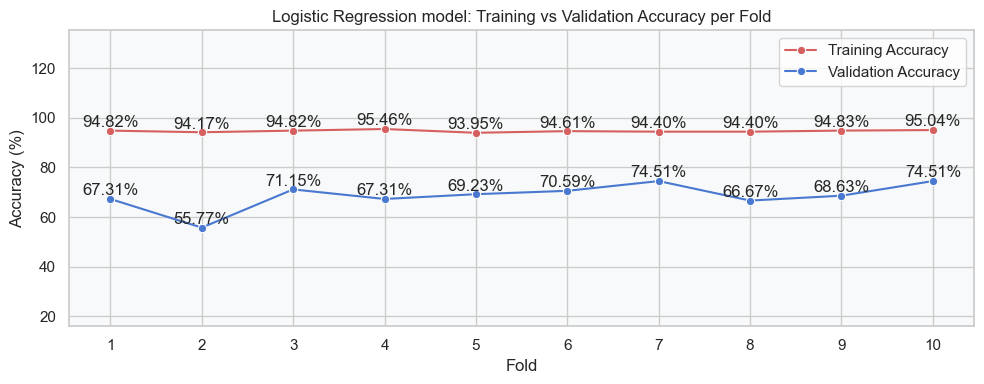

In [395]:
display_each_fold_result("Logistic Regression",lr_each_fold_results)

Model 2: SVM

In [150]:
svm_model= create_ml_model('svm', random_state=1, C=100, kernel='rbf',probability=True, gamma='scale',tol=0.00001, class_weight='balanced',)

In [151]:
svm_model, svm_each_fold_results, svm_results = kfold_evaluation(svm_model, X_train, y_train, skf,groups)

In [152]:
display_all_folds_results("SVM", svm_results)

Average SVM Performance Metrics Across All Folds (on validation data):
- Accuracy: 82.71%
- Precision: 0.8336
- Recall: 0.8271
- F1 Score: 0.8263


SVM Performance Metrics Across Each Fold (on training and validation data):

Fold  | Training Metrics                                                       | Validation Metrics                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Accuracy: 100.00, Precision: 1.00, Recall: 1.00, F1: 1.00              | Accuracy: 82.69, Precision: 0.83, Recall: 0.83, F1: 0.83              
2     | Accuracy: 100.00, Precision: 1.00, Recall: 1.00, F1: 1.00              | Accuracy: 78.85, Precision: 0.80, Recall: 0.79, F1: 0.79              
3     | Accuracy: 100.00, Precision: 1.00, Recall: 1.00, F1: 1.00              | Accuracy: 86.54, Precision: 0.87, Recall: 0.87, F1: 0.86              
4     | Accuracy: 100.00, Precision: 1.00, Recall: 1.00, F1: 1.00              | Accuracy: 86.54, Precision: 0.87, Recall: 0.87, F1: 0.86              
5     | Accu

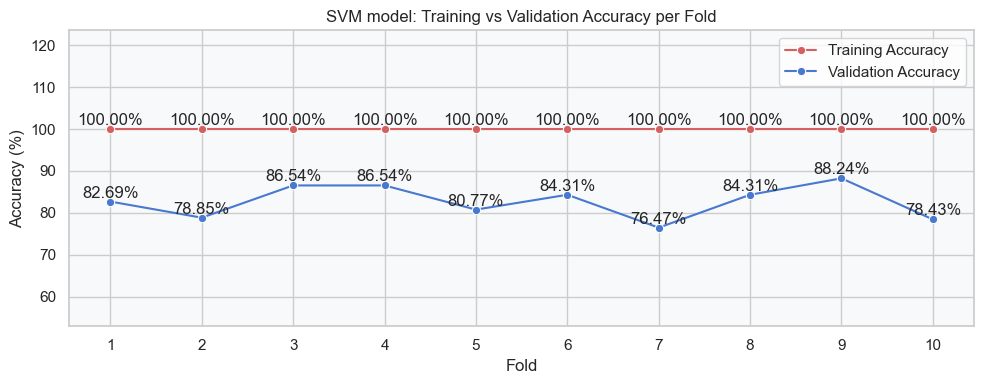

In [153]:
display_each_fold_result("SVM",svm_each_fold_results)

Model 4: XGB

In [27]:
xgb_model= create_ml_model('xgb', learning_rate=0.1, max_depth=3, n_estimators=100,objective='binary:logistic',random_state=1)

In [30]:
xgb_model, xgb_each_fold_results, xgb_results = kfold_evaluation(xgb_model, X_train, y_train, skf)

In [31]:
display_all_folds_results("XGB", xgb_results)

Average XGB Performance Metrics Across All Folds (on validation data):
- Accuracy: 70.46%
- Precision: 0.7084
- Recall: 0.7046
- F1 Score: 0.7037


XGB Performance Metrics Across Each Fold (on training and validation data):

Fold  | Training Metrics                                                       | Validation Metrics                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Accuracy: 100.00, Precision: 1.00, Recall: 1.00, F1: 1.00              | Accuracy: 68.63, Precision: 0.69, Recall: 0.69, F1: 0.69              
2     | Accuracy: 100.00, Precision: 1.00, Recall: 1.00, F1: 1.00              | Accuracy: 80.39, Precision: 0.80, Recall: 0.80, F1: 0.80              
3     | Accuracy: 100.00, Precision: 1.00, Recall: 1.00, F1: 1.00              | Accuracy: 76.47, Precision: 0.77, Recall: 0.76, F1: 0.76              
4     | Accuracy: 100.00, Precision: 1.00, Recall: 1.00, F1: 1.00              | Accuracy: 72.55, Precision: 0.74, Recall: 0.73, F1: 0.72              
5     | Accu

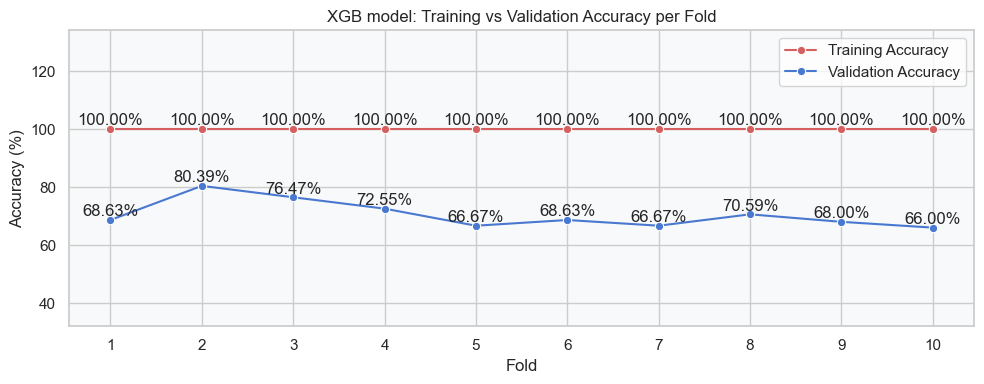

In [32]:
display_each_fold_result("XGB",xgb_each_fold_results)

Fit all train

In [33]:
model=xgb_model

In [ ]:
model.fit(X_train, y_train)

Prediction_train

In [ ]:
proba_train1 = cross_val_predict(model, X_train, y_train, cv=skf, method='predict_proba')
[print(x) for x in proba_train1[:,1]]

In [ ]:
dframe_train=pd.DataFrame({'SampleID':train['SampleID'],'Class':train['Class'],'Label':train['Label'],'Probability':proba_train1[:,1]})

Prediction_test

In [ ]:
y_pred = model.predict_proba(X_test)
print(y_pred)

In [ ]:
dframe=pd.DataFrame({'SampleID':test['SampleID'],'Class':test['Class'],'Label':test['Label'],'Probability':y_pred[:,1]})

In [ ]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (8,8))
sns.set_theme(context='notebook', style='ticks', palette='deep', font='sans-serif', font_scale=1.4, color_codes=True, rc=None)

# #CNN
fpr_TRAIN, tpr_TRAIN, thresholds_TRAIN = metrics.roc_curve(y_train,  proba_train1[:, 1])
auc_TRAIN = metrics.roc_auc_score(y_train,  proba_train1[:, 1])
plt.plot(fpr_TRAIN,tpr_TRAIN,label="AUC training = "+str(round(auc_TRAIN, 4)), linewidth = 3, color='green')


fpr_TEST, tpr_TEST, thresholds_TEST = metrics.roc_curve(y_test,  y_pred[:, 1])
auc_TEST = metrics.roc_auc_score(y_test,  y_pred[:, 1])
plt.plot(fpr_TEST,tpr_TEST,label="AUC testing = "+str(round(auc_TEST, 4)), linewidth = 3, color='royalblue')

# 
plt.plot([0, 1], ls="--")
plt.title('1D model', fontsize=20, fontweight='bold')
plt.ylabel('Sensitivity', labelpad=10, fontsize=20, fontweight='bold')
plt.xlabel('1-Specificity', labelpad=10, fontsize=20, fontweight='bold')
legend=plt.legend(loc=4, fontsize=18)
#plt.plot([0.05,0.05],[1,0],color = 'k', label = 'Fold Change = 2',linestyle = ':', linewidth=1)

legend.get_frame().set_linewidth(0) 

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tick_params(axis='both', which='major', labelsize=18)

# Show the plot
plt.show()